In [111]:
!pip install -q pytorch-lightning

In [112]:
!wget https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv

--2024-10-30 15:13:09--  https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54288 (53K) [text/plain]
Saving to: ‘insurance.csv.2’

insurance.csv.2     100%[===================>]  53.02K  --.-KB/s    in 0.009s  

2024-10-30 15:13:09 (5.61 MB/s) - ‘insurance.csv.2’ saved [54288/54288]



In [113]:
import pandas as pd # pandas for data manipulation
import numpy as np # numpy for linear algebra
import matplotlib.pyplot as plt # matplotlib for plotting
import seaborn as sns # seaborn for plotting

In [114]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [116]:
df = pd.get_dummies(df, drop_first=True) # we have to talk about drop_first -> avoid the dummy variable trap
df

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [117]:
df.dtypes

,0
age,int64
bmi,float64
children,int64
charges,float64
sex_male,bool
smoker_yes,bool
region_northwest,bool
region_southeast,bool
region_southwest,bool


In [118]:
df.iloc[:, :4] = df.iloc[:, :4].astype('float32')

<ipython-input-118-890d8b6fbeb9>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       19.0
1       18.0
2       28.0
3       33.0
4       32.0
        ... 
1333    50.0
1334    18.0
1335    18.0
1336    21.0
1337    61.0
Name: age, Length: 1338, dtype: float32' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[:, :4] = df.iloc[:, :4].astype('float32')
<ipython-input-118-890d8b6fbeb9>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       0.0
1       1.0
2       3.0
3       0.0
4       0.0
       ... 
1333    3.0
1334    0.0
1335    0.0
1336    0.0
1337    0.0
Name: children, Length: 1338, dtype: float32' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[:, :4] = df.iloc[:, :4].astype('float32')


In [119]:
df.dtypes

,0
age,float32
bmi,float64
children,float32
charges,float64
sex_male,bool
smoker_yes,bool
region_northwest,bool
region_southeast,bool
region_southwest,bool


In [120]:
X = df.drop(columns=['charges']).values # features
y = df['charges'].values # label

In [121]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import torchmetrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import numpy as np

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [144]:
batch_size = 64
epochs = 120
lr = 0.002
out_dim = 1

In [145]:
def create_dataloader(X, y, batch_size):
    X = scaler.transform(X).astype('float32')
    X = torch.from_numpy(X)
    y = y.astype('float32')
    y = torch.from_numpy(y)
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

train_loader = create_dataloader(X_train, y_train, batch_size)
val_loader = create_dataloader(X_val, y_val, batch_size)
test_loader = create_dataloader(X_test, y_test, batch_size)

In [174]:
class MyFeedForwardNet(pl.LightningModule):
    def __init__(self, input_dim, output_dim, lr):
        super(MyFeedForwardNet, self).__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.layers = nn.Sequential(
           nn.Linear(input_dim, 512),
           nn.ReLU(),
           nn.Dropout(0.2),
           nn.BatchNorm1d(512),  # Batch Normalization
           nn.Linear(512, 256),
           nn.ReLU(),
           nn.Dropout(0.2),
           nn.BatchNorm1d(256),  # Batch Normalization
           nn.Linear(256, 64),
           nn.ReLU(),
           nn.Dropout(0.2),
           nn.BatchNorm1d(64),  # Batch Normalization
           nn.Linear(64, output_dim)
      )
        self.loss = nn.BCELoss()
        self.acc = torchmetrics.classification.BinaryAccuracy()
        self.mae = torchmetrics.MeanAbsoluteError()

        # forward propagation
    def forward(self, x):
      return self.layers(x)

    # one step of training
    def training_step(self, batch, batch_idx):
      loss, acc = self._shared_eval_step(batch, batch_idx)
      metrics = {"acc": acc, "loss": loss}
      self.log_dict(metrics, prog_bar=True)
      return metrics

    # one step of validation
    def validation_step(self, batch, batch_idx):
      loss, acc = self._shared_eval_step(batch, batch_idx)
      metrics = {"val_acc": acc, "val_loss": loss}
      self.log_dict(metrics, prog_bar=True)
      return metrics

    # one step of test
    def test_step(self, batch, batch_idx):
      loss, acc = self._shared_eval_step(batch, batch_idx)
      metrics = {"test_acc": acc, "test_loss": loss}
      self.log_dict(metrics)
      return metrics

    def _shared_eval_step(self, batch, batch_idx):
      x, y = batch
      y_hat = self(x).squeeze()
      y_hat = F.sigmoid(y_hat)
      loss = self.loss(y_hat, y)
      acc = self.acc(y_hat, y)
      return loss, acc

    # we use the AdamW optimizer
    def configure_optimizers(self):
      return torch.optim.AdamW(self.parameters(), lr=self.lr)

logger = pl.loggers.TensorBoardLogger("logs/", name="heart_disease_logs")

batch_size = 64
epochs = 120
lr = 0.002
output_dim = 1

# we instantiate our model
model = MyFeedForwardNet(X_train.shape[1], output_dim, lr)

# we use the ModelCheckpoint callback to save the best model
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor='val_loss', # You should monitor val_loss instead of val_mae
    dirpath='./checkpoints/', # Define a specific directory to store checkpoints
    filename='best_model-{epoch:02d}-{val_loss:.2f}', # A good file name convention
    save_top_k=1,
    mode='min'
)

# we use the Trainer class to train our model
trainer = pl.Trainer(
    max_epochs=epochs,
    callbacks=[checkpoint_callback]
)




INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [175]:
trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.callbacks.model_summary:
  | Name   | Type              | Params | Mode 
-----------------------------------------------------
0 | layers | Sequential        | 160 K  | train
1 | loss   | BCELoss           | 0      | train
2 | acc    | BinaryAccuracy    | 0      | train
3 | mae    | MeanAbsoluteError | 0      | train
-----------------------------------------------------
160 K     Trainable params
0         Non-trainable params
160 K     Total params
0.641     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:475: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/loops/fit_loop.py:298: The number of training batches (13) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=120` reached.


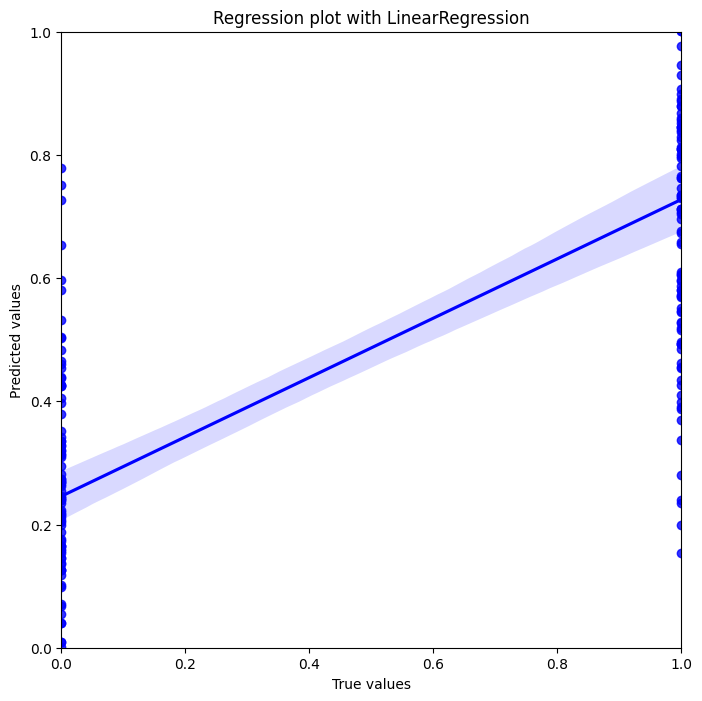

LinearRegression - Mean absolute error: 0.2977885633012667
LinearRegression - Coefficient of determination: 0.48068045863928854


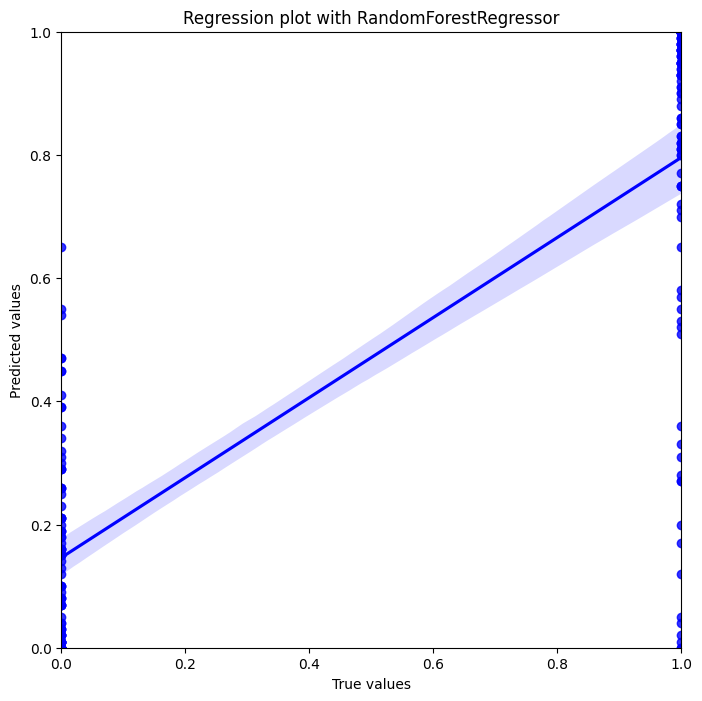

RandomForestRegressor - Mean absolute error: 0.1772
RandomForestRegressor - Coefficient of determination: 0.6502301276253643
Best model: RandomForestRegressor with MAE: 0.1772 and R2: 0.6502301276253643
Checkpoint file not found. Ensure the checkpoint exists and the path is correct.


In [184]:
# Initialize a dictionary to store results
results = {}

# Train and evaluate both models
for model in [LinearRegression(), RandomForestRegressor()]:
    model_name = model.__class__.__name__
    model.fit(scaler.transform(X_train), y_train)
    y_pred = model.predict(scaler.transform(X_test))

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results in the dictionary
    results[model_name] = {'MAE': mae, 'R2': r2}

    # Display regression plot
    plt.figure(figsize=(8, 8))
    sns.regplot(x=y_test, y=y_pred, scatter=True, color='b')
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.xlim(min(y_test), max(y_test))
    plt.ylim(min(y_test), max(y_test))
    plt.title(f"Regression plot with {model_name}")
    plt.show()

    print(f"{model_name} - Mean absolute error: {mae}")
    print(f"{model_name} - Coefficient of determination: {r2}")

# Identify the best model based on MAE and R2
linear_mae = results['LinearRegression']['MAE']
linear_r2 = results['LinearRegression']['R2']

best_model = None
best_mae = float('inf')
best_r2 = float('-inf')

for model_name, metrics in results.items():
    if metrics['MAE'] < linear_mae and metrics['R2'] > linear_r2:
        best_model = model_name
        best_mae = metrics['MAE']
        best_r2 = metrics['R2']

# If a suitable best model is found, save it to a CSV file
if best_model:
    df_results = pd.DataFrame([[best_model, best_mae, best_r2]], columns=['Model', 'MAE', 'R2'])
    df_results.to_csv("mlp_results.csv", index=False)
    print(f"Best model: {best_model} with MAE: {best_mae} and R2: {best_r2}")
else:
    print("No suitable best model found.")

# Load the best performing model (example usage)
# Assuming you have saved a checkpoint during training using the ModelCheckpoint callback
# You should replace 'best_model.ckpt' with the actual filename of your saved checkpoint.
# Note: make sure checkpoints/ contains saved checkpoints using checkpoint_callback in Trainer
try:
    best_model_path = "./checkpoints/best_model.ckpt"  # Update with actual checkpoint filename
    best_model_instance = MyFeedForwardNet.load_from_checkpoint(best_model_path)
    print("Successfully loaded model from checkpoint:", best_model_path)
except FileNotFoundError:
    print("Checkpoint file not found. Ensure the checkpoint exists and the path is correct.")


In [183]:

y_pred_mlp = model.predict(X_test)
np.save("MyFeedForwardNet.npy", y_pred_mlp)

y_pred_rf = model.predict(X_test)
np.save("RandomForestRegressor.npy", y_pred_rf)


y_pred_mlp = np.load("MyFeedForwardNet.npy")
y_pred_rf = np.load("RandomForestRegressor.npy")


y_pred_ensemble = 0.5 * y_pred_mlp + 0.5 * y_pred_rf


mae_ensemble = mean_absolute_error(y_test, y_pred_ensemble)
r2_ensemble = r2_score(y_test, y_pred_ensemble)


print(f"Ensemble Mean Absolute Error: {mae_ensemble}")
print(f"Ensemble Coefficient of Determination: {r2_ensemble}")


ensemble_results = pd.DataFrame({
    "Model": ["Ensemble"],
    "MAE": [mae_ensemble],
    "R2": [r2_ensemble]
})

ensemble_results.to_csv("ensemble_results.csv", index=False)


Ensemble Mean Absolute Error: 0.19884999999999997
Ensemble Coefficient of Determination: 0.5471952567581148
